# 03_OPTIMISATION_SEUIL_EXPLICABILITÉ

## Objectif

Ce notebook reprend directement le **modèle retenu à la fin du notebook 02** et cherche à l'améliorer de façon simple et lisible :

- partir du meilleur candidat baseline ;
- optimiser ses hyperparamètres avec validation croisée ;
- utiliser une métrique métier où les faux négatifs coûtent plus cher que les faux positifs ;
- régler le seuil de décision ;
- comparer baseline, modèle optimisé au seuil `0.5` et modèle optimisé au seuil métier ;
- documenter le lien entre performances techniques et performances métier ;
- produire des sorties d'explicabilité ;
- enregistrer à la fin le modèle optimisé dans MLflow Model Registry.

La logique suit l'esprit du notebook exemple :

1. split final sanctuarisé ;
2. rappel du candidat retenu ;
3. tuning du modèle ;
4. réglage du seuil ;
5. test final sur le holdout ;
6. explicabilité ;
7. enregistrement final.

Dans notre configuration actuelle, le candidat retenu est `lightgbm_bonus` :
le notebook impose donc un entraînement **sur GPU** pour rester cohérent avec la
stratégie de performance choisie.


In [1]:
from functools import partial
from pathlib import Path
from contextlib import redirect_stderr, redirect_stdout
import importlib
import io
import json
import sys
import warnings

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.tracking.fluent as mlflow_fluent
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from mlflow import MlflowClient
from mlflow.exceptions import MlflowException
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

try:
    import shap
    shap_available = True
except ImportError:
    shap = None
    shap_available = False

warnings.filterwarnings("ignore", category=UserWarning)

def resolve_project_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        "Impossible de localiser la racine du projet contenant 'src/' et 'data/'."
    )

project_root = resolve_project_root(Path.cwd())

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.Fonctions_MODEL as fonctions_model
fonctions_model = importlib.reload(fonctions_model)

DEFAULT_REGISTERED_MODEL_NAME = fonctions_model.DEFAULT_REGISTERED_MODEL_NAME
build_baseline_benchmark_catalog = fonctions_model.build_baseline_benchmark_catalog
build_classification_tuning_guide = fonctions_model.build_classification_tuning_guide
build_lightgbm_estimator = fonctions_model.build_lightgbm_estimator
build_optimization_candidate = fonctions_model.build_optimization_candidate
classification_metrics_at_threshold = fonctions_model.classification_metrics_at_threshold
configure_mlflow_tracking = fonctions_model.configure_mlflow_tracking
evaluate_classifier_cv = fonctions_model.evaluate_classifier_cv
flatten_cv_summary = fonctions_model.flatten_cv_summary
get_classification_tuning_grid = fonctions_model.get_classification_tuning_grid
plot_threshold_diagnostics = fonctions_model.plot_threshold_diagnostics
prepare_modeling_tables = fonctions_model.prepare_modeling_tables
register_model_version = fonctions_model.register_model_version
resolve_lightgbm_device_type = fonctions_model.resolve_lightgbm_device_type
save_figure = fonctions_model.save_figure
score_to_probability = fonctions_model.score_to_probability
threshold_search = fonctions_model.threshold_search

processed_dir = project_root / "data" / "processed"
report_dir = processed_dir / "reports"
explain_dir = report_dir / "explainability"
explain_dir.mkdir(parents=True, exist_ok=True)

tracking_context = configure_mlflow_tracking(project_root)
tracking_uri = tracking_context.tracking_uri
experiment_name = tracking_context.experiment_name

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

random_state = 42
cv_folds = 3
business_fn_cost = 10.0
business_fp_cost = 1.0
threshold_grid = np.arange(0.10, 0.91, 0.01)
lightgbm_device_type = resolve_lightgbm_device_type(random_state=random_state)
compact_metric_keys = [
    "accuracy",
    "f1",
    "business_fbeta",
    "roc_auc",
    "pr_auc",
    "business_cost_per_obs",
]
aligned_metric_keys = [
    "accuracy",
    "f1",
    "business_fbeta",
    "roc_auc",
    "pr_auc",
]

def compute_search_space_size(param_grid: dict[str, list]) -> int:
    total = 1
    for values in param_grid.values():
        total *= len(values)
    return total

def build_cv_metric_row(version: str, summary_flat: dict) -> dict:
    row = {"version": version}
    for metric in compact_metric_keys:
        row[f"train_{metric}"] = float(summary_flat.get(f"train_{metric}_mean", np.nan))
        row[f"valid_{metric}"] = float(summary_flat.get(f"valid_{metric}_mean", np.nan))
    return row

def build_holdout_metric_row(version: str, threshold: float, metrics: dict) -> dict:
    row = {
        "version": version,
        "threshold": float(threshold),
    }
    for metric in compact_metric_keys:
        row[metric] = float(metrics.get(metric, np.nan))
    row["precision"] = float(metrics.get("precision", np.nan))
    row["recall"] = float(metrics.get("recall", np.nan))
    return row

def build_train_test_metric_row(
    version: str,
    threshold: float,
    train_metrics: dict,
    test_metrics: dict,
) -> dict:
    row = {"version": version}
    for metric in aligned_metric_keys:
        row[f"train_{metric}"] = float(train_metrics.get(metric, np.nan))
        row[f"test_{metric}"] = float(test_metrics.get(metric, np.nan))
    row["train_business_cost_per_obs"] = float(
        train_metrics.get("business_cost_per_obs", np.nan)
    )
    row["test_business_cost_per_obs"] = float(
        test_metrics.get("business_cost_per_obs", np.nan)
    )
    row["threshold"] = float(threshold)
    return row

def log_cv_summary_metrics(prefix: str, summary_flat: dict) -> None:
    payload = {}
    for split in ("train", "valid"):
        for metric in compact_metric_keys:
            source_key = f"{split}_{metric}_mean"
            if source_key in summary_flat:
                payload[f"{prefix}_{split}_{metric}"] = float(summary_flat[source_key])
    if payload:
        mlflow.log_metrics(payload)

def log_metric_group(prefix: str, metrics: dict) -> None:
    payload = {}
    for metric in compact_metric_keys:
        if metric in metrics:
            payload[f"{prefix}_{metric}"] = float(metrics[metric])
    if "precision" in metrics:
        payload[f"{prefix}_precision"] = float(metrics["precision"])
    if "recall" in metrics:
        payload[f"{prefix}_recall"] = float(metrics["recall"])
    if payload:
        mlflow.log_metrics(payload)

def log_train_test_metrics(train_metrics: dict, test_metrics: dict) -> None:
    payload = {}
    for metric in aligned_metric_keys:
        if metric in train_metrics:
            payload[f"train_{metric}"] = float(train_metrics[metric])
        if metric in test_metrics:
            payload[f"test_{metric}"] = float(test_metrics[metric])
    if payload:
        mlflow.log_metrics(payload)

def log_train_test_metric_group(
    prefix: str,
    train_metrics: dict,
    test_metrics: dict,
) -> None:
    payload = {}
    for metric in aligned_metric_keys:
        if metric in train_metrics:
            payload[f"{prefix}_train_{metric}"] = float(train_metrics[metric])
        if metric in test_metrics:
            payload[f"{prefix}_test_{metric}"] = float(test_metrics[metric])
    for side, metrics in (("train", train_metrics), ("test", test_metrics)):
        if "business_cost_per_obs" in metrics:
            payload[f"{prefix}_{side}_business_cost_per_obs"] = float(
                metrics["business_cost_per_obs"]
            )
    if payload:
        mlflow.log_metrics(payload)

def prepare_explainability_frame(fitted_model, X_frame: pd.DataFrame):
    if hasattr(fitted_model, "named_steps"):
        core_model = fitted_model.named_steps["model"]
        preprocess = fitted_model[:-1]
        transformed = preprocess.transform(X_frame)
        if hasattr(transformed, "toarray"):
            transformed = transformed.toarray()
        explain_frame = pd.DataFrame(
            transformed,
            index=X_frame.index,
            columns=X_frame.columns,
        )
        return core_model, explain_frame
    return fitted_model, X_frame.copy()

def compute_native_importance(fitted_model, X_frame: pd.DataFrame) -> pd.DataFrame:
    core_model, explain_frame = prepare_explainability_frame(fitted_model, X_frame)

    if hasattr(core_model, "feature_importances_"):
        importance_values = np.asarray(core_model.feature_importances_, dtype=float)
        importance_type = "feature_importances_"
    elif hasattr(core_model, "coef_"):
        coef = np.asarray(core_model.coef_, dtype=float)
        importance_values = np.abs(coef).ravel()
        importance_type = "abs_standardized_coef"
    else:
        return pd.DataFrame(columns=["feature", "importance", "importance_type"])

    return (
        pd.DataFrame(
            {
                "feature": explain_frame.columns,
                "importance": importance_values,
                "importance_type": importance_type,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

def business_threshold_cv_score(
    estimator,
    X_eval,
    y_eval,
    fn_cost: float,
    fp_cost: float,
    thresholds: np.ndarray,
) -> float:
    y_scores = score_to_probability(estimator, X_eval)
    _, best_row = threshold_search(
        y_true=y_eval,
        y_scores=y_scores,
        thresholds=thresholds,
        fn_cost=fn_cost,
        fp_cost=fp_cost,
    )
    return -float(best_row["business_cost_per_obs"])

def clear_deleted_mlflow_runs_from_stack() -> int:
    cleared = 0
    client = MlflowClient()
    stack = mlflow_fluent._active_run_stack.get()

    while mlflow.active_run() is not None:
        run_id = mlflow.active_run().info.run_id
        lifecycle_stage = None
        try:
            lifecycle_stage = client.get_run(run_id).info.lifecycle_stage
        except Exception:
            lifecycle_stage = None

        if lifecycle_stage == "active":
            break

        stack.pop()
        cleared += 1

    return cleared

def safe_end_active_run() -> str:
    cleared = clear_deleted_mlflow_runs_from_stack()
    if cleared > 0 and mlflow.active_run() is None:
        return f"cleared_deleted_runs:{cleared}"

    active_run = mlflow.active_run()
    if active_run is None:
        return "no_active_run"

    run_id = active_run.info.run_id
    try:
        mlflow.end_run()
        return f"ended:{run_id}"
    except MlflowException as exc:
        if "Current state is deleted" in str(exc) or "must be in the 'active' state" in str(exc):
            cleared += clear_deleted_mlflow_runs_from_stack()
            return f"cleared_deleted_runs:{cleared}"
        raise

def resolve_lightgbm_gpu_target(random_state: int = 42):
    if lgb is None:
        return None

    probe_X = pd.DataFrame(
        np.random.default_rng(seed=random_state).random((2048, 16), dtype=np.float32)
    )
    probe_y = pd.Series(
        np.random.default_rng(seed=random_state + 1).integers(0, 2, size=2048)
    )

    candidates = []
    for platform_id in range(4):
        for device_id in range(4):
            log_buffer = io.StringIO()
            try:
                probe_model = build_lightgbm_estimator(
                    random_state=random_state,
                    device_type="gpu",
                    n_estimators=5,
                    verbosity=2,
                    gpu_platform_id=platform_id,
                    gpu_device_id=device_id,
                )
                with redirect_stdout(log_buffer), redirect_stderr(log_buffer):
                    probe_model.fit(probe_X, probe_y)
                log_text = log_buffer.getvalue()
                device_line = next(
                    (
                        line.strip()
                        for line in log_text.splitlines()
                        if "Using GPU Device:" in line
                    ),
                    "",
                )
                if not device_line:
                    continue

                device_name = (
                    device_line.split("Using GPU Device:", 1)[1]
                    .split(", Vendor:", 1)[0]
                    .strip()
                )
                vendor = (
                    device_line.split("Vendor:", 1)[1].strip()
                    if "Vendor:" in device_line
                    else "unknown"
                )
                candidates.append(
                    {
                        "gpu_platform_id": platform_id,
                        "gpu_device_id": device_id,
                        "gpu_device_name": device_name,
                        "gpu_vendor": vendor,
                    }
                )
            except Exception:
                continue

    if not candidates:
        return None

    candidates.sort(
        key=lambda item: (
            0 if "nvidia" in item["gpu_vendor"].lower() else 1,
            item["gpu_platform_id"],
            item["gpu_device_id"],
        )
    )
    return candidates[0]

lightgbm_gpu_target = (
    resolve_lightgbm_gpu_target(random_state=random_state)
    if lightgbm_device_type == "gpu"
    else None
)

print("Python executable      :", sys.executable)
print("Tracking URI           :", tracking_uri)
print("Experiment             :", experiment_name)
print("LightGBM device_type   :", lightgbm_device_type)
if lightgbm_gpu_target is not None:
    print(
        "LightGBM GPU target    :",
        f"{lightgbm_gpu_target['gpu_device_name']} "
        f"(vendor={lightgbm_gpu_target['gpu_vendor']}, "
        f"platform={lightgbm_gpu_target['gpu_platform_id']}, "
        f"device={lightgbm_gpu_target['gpu_device_id']})",
    )
print("Seuils testés          :", f"{threshold_grid.min():.2f} -> {threshold_grid.max():.2f}")
print("UI command             : uv run mlflow ui --backend-store-uri", tracking_uri)
print("SHAP disponible        :", shap_available)


Python executable      : c:\Users\kevin\Documents\P6\P6_MLOps_1-2\.venv\Scripts\python.exe
Tracking URI           : sqlite:///C:/Users/kevin/Documents/P6/P6_MLOps_1-2/mlflow.db
Experiment             : P6_HOME_CREDIT_DEFAULT_RISK
LightGBM device_type   : gpu
LightGBM GPU target    : NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU (vendor=NVIDIA Corporation, platform=1, device=0)
Seuils testés          : 0.10 -> 0.90
UI command             : uv run mlflow ui --backend-store-uri sqlite:///C:/Users/kevin/Documents/P6/P6_MLOps_1-2/mlflow.db
SHAP disponible        : True


## 1. Charger les données et sanctuariser le holdout final

Comme dans le notebook exemple, on commence par isoler **un jeu final de test interne** qui ne sera utilisé qu'à la fin.

Ensuite :

- on recharge le résultat du notebook 02 ;
- on récupère automatiquement le modèle recommandé pour la suite ;
- on prépare la grille de tuning adaptée à ce modèle ;
- si ce modèle est `lightgbm_bonus`, on vérifie explicitement que le GPU est disponible
  et on cible la bonne plateforme OpenCL.


In [2]:
train_full = pd.read_parquet(processed_dir / "application_train_full.parquet")
test_full = pd.read_parquet(processed_dir / "application_test_full.parquet")

baseline_leaderboard_path = processed_dir / "baseline_leaderboard.csv"
recommendation_path = processed_dir / "model_recommendation.json"

if baseline_leaderboard_path.exists():
    baseline_leaderboard = pd.read_csv(baseline_leaderboard_path)
else:
    baseline_leaderboard = pd.DataFrame()

if recommendation_path.exists():
    recommendation = json.loads(recommendation_path.read_text(encoding="utf-8"))
else:
    recommendation = {}

X, y, X_test, quality_report = prepare_modeling_tables(
    train_df=train_full,
    test_df=test_full,
    id_col="SK_ID_CURR",
    target_col="TARGET",
    missing_threshold=0.95,
)

train_ids = train_full["SK_ID_CURR"].copy()
test_ids = test_full["SK_ID_CURR"].copy()

X_model, X_holdout, y_model, y_holdout, ids_model, ids_holdout = train_test_split(
    X,
    y,
    train_ids,
    test_size=0.20,
    random_state=random_state,
    stratify=y,
)

benchmark_catalog = build_baseline_benchmark_catalog()
available_models = benchmark_catalog["model_name"].tolist()
recommended_model_name = recommendation.get("model_retained_for_optimization")

if recommended_model_name in available_models:
    selected_model_name = recommended_model_name
    selection_source = "notebook_02"
else:
    selected_model_name = "lightgbm_bonus"
    selection_source = "fallback_default"

if selected_model_name == "lightgbm_bonus" and lightgbm_device_type != "gpu":
    raise RuntimeError(
        "Le notebook 03 impose LightGBM sur GPU pour le modèle retenu "
        "(`lightgbm_bonus`), mais aucun GPU compatible n'a été détecté."
    )
if selected_model_name == "lightgbm_bonus" and lightgbm_gpu_target is None:
    raise RuntimeError(
        "Le notebook 03 n'a pas réussi à identifier une cible OpenCL exploitable "
        "pour LightGBM sur GPU."
    )

selected_model_family = benchmark_catalog.set_index("model_name").loc[selected_model_name, "family"]
selected_model_why = benchmark_catalog.set_index("model_name").loc[selected_model_name, "why_included"]

selected_model = build_optimization_candidate(
    model_name=selected_model_name,
    random_state=random_state,
    lightgbm_device_type=lightgbm_device_type,
)
if selected_model_name == "lightgbm_bonus" and lightgbm_gpu_target is not None:
    selected_model.set_params(
        gpu_platform_id=lightgbm_gpu_target["gpu_platform_id"],
        gpu_device_id=lightgbm_gpu_target["gpu_device_id"],
    )
tuning_grid = get_classification_tuning_grid(selected_model_name)
tuning_guide = build_classification_tuning_guide(selected_model_name)
search_space_size = compute_search_space_size(tuning_grid)

selection_context = pd.DataFrame(
    [
        {
            "selected_model_name": selected_model_name,
            "selected_model_family": selected_model_family,
            "selection_source": selection_source,
            "why_included": selected_model_why,
            "search_space_size": search_space_size,
            "model_rows": X_model.shape[0],
            "holdout_rows": X_holdout.shape[0],
            "class_rate_model": float(y_model.mean()),
            "class_rate_holdout": float(y_holdout.mean()),
            "lightgbm_gpu_platform_id": (
                lightgbm_gpu_target["gpu_platform_id"]
                if lightgbm_gpu_target is not None
                else None
            ),
            "lightgbm_gpu_device_id": (
                lightgbm_gpu_target["gpu_device_id"]
                if lightgbm_gpu_target is not None
                else None
            ),
            "lightgbm_gpu_vendor": (
                lightgbm_gpu_target["gpu_vendor"]
                if lightgbm_gpu_target is not None
                else None
            ),
            "lightgbm_gpu_name": (
                lightgbm_gpu_target["gpu_device_name"]
                if lightgbm_gpu_target is not None
                else None
            ),
        }
    ]
)

print("X_model shape   :", X_model.shape)
print("X_holdout shape :", X_holdout.shape)
print("Taux de défaut model   :", round(float(y_model.mean()), 6))
print("Taux de défaut holdout :", round(float(y_holdout.mean()), 6))
print("Modèle retenu :", selected_model_name)
print("Famille :", selected_model_family)
print("Source de sélection :", selection_source)
if selected_model_name == "lightgbm_bonus":
    print(
        "Exécution LightGBM :",
        f"GPU confirmé sur {lightgbm_gpu_target['gpu_device_name']}",
    )
print("Taille de la grille GridSearchCV :", search_space_size)

display(selection_context)
display(tuning_guide)

if not baseline_leaderboard.empty:
    baseline_display_columns = [
        "model_name",
        "family",
        "valid_business_fbeta_mean",
        "valid_pr_auc_mean",
        "valid_roc_auc_mean",
        "holdout_business_fbeta",
        "holdout_pr_auc",
        "holdout_roc_auc",
        "valid_business_cost_per_obs_mean",
    ]
    available_display_columns = [
        column for column in baseline_display_columns
        if column in baseline_leaderboard.columns
    ]
    display(baseline_leaderboard[available_display_columns].head(10))


X_model shape   : (246005, 733)
X_holdout shape : (61502, 733)
Taux de défaut model   : 0.08073
Taux de défaut holdout : 0.080729
Modèle retenu : lightgbm_bonus
Famille : Boosting externe
Source de sélection : notebook_02
Exécution LightGBM : GPU confirmé sur NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU
Taille de la grille GridSearchCV : 16


,selected_model_name,selected_model_family,selection_source,why_included,search_space_size,model_rows,holdout_rows,class_rate_model,class_rate_holdout,lightgbm_gpu_platform_id,lightgbm_gpu_device_id,lightgbm_gpu_vendor,lightgbm_gpu_name
0,lightgbm_bonus,Boosting externe,notebook_02,benchmark bonus plus puissant et bon candidat ...,16,246005,61502,0.08073,0.080729,1,0,NVIDIA Corporation,NVIDIA RTX PRO 5000 Blackwell Generation Lapto...


,model_name,hyperparameter,role,baseline_value,search_values
0,lightgbm_bonus,learning_rate,pas d'apprentissage,0.05,"[0.03, 0.05]"
1,lightgbm_bonus,num_leaves,complexité des arbres LightGBM,31.00,"[31, 63]"
2,lightgbm_bonus,min_child_samples,taille minimale d'une feuille LightGBM,20.00,"[20, 100]"
3,lightgbm_bonus,reg_lambda,régularisation L2 LightGBM,0.00,"[0.0, 1.0]"


,model_name,family,valid_business_fbeta_mean,valid_pr_auc_mean,valid_roc_auc_mean,holdout_business_fbeta,holdout_pr_auc,holdout_roc_auc,valid_business_cost_per_obs_mean
0,lightgbm_bonus,Booster bonus,0.540661,0.272530,0.782604,0.556560,0.286739,0.787233,0.496514
1,sgd_log_loss,Baseline linéaire,0.504792,0.183174,0.724703,0.518351,0.194601,0.736234,0.571057
2,hist_gradient_boosting,Booster scikit-learn,0.041693,0.271995,0.782295,0.050137,0.284827,0.785932,0.779033
3,dummy_classifier,Baseline naïve,0.000000,0.080730,0.500000,0.000000,0.080729,0.500000,0.807301


## 2. Point de départ : performance baseline du modèle retenu

Avant toute optimisation, on recalcule la performance de départ du modèle retenu sur le bloc `X_model`.

Cela permet de répondre clairement à la question :
**le tuning apporte-t-il réellement un gain par rapport à la baseline ?**


In [3]:
baseline_cv_folds, baseline_cv_summary = evaluate_classifier_cv(
    model=selected_model,
    X=X_model,
    y=y_model,
    cv=cv_folds,
    threshold=0.5,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
    random_state=random_state,
)

baseline_summary_flat = flatten_cv_summary(baseline_cv_summary)
baseline_cv_overview = pd.DataFrame(
    [build_cv_metric_row("baseline_default_0_5", baseline_summary_flat)]
)

display(baseline_cv_overview)


,version,train_accuracy,valid_accuracy,train_f1,valid_f1,train_business_fbeta,valid_business_fbeta,train_roc_auc,valid_roc_auc,train_pr_auc,valid_pr_auc,train_business_cost_per_obs,valid_business_cost_per_obs
0,baseline_default_0_5,0.775663,0.751891,0.370091,0.299854,0.669536,0.540659,0.877378,0.782609,0.411255,0.272553,0.357798,0.496518


## 3. Optimisation des hyperparamètres

On optimise directement le modèle retenu à l'étape baseline.

La `GridSearchCV` est pilotée par une métrique métier personnalisée :

- on produit des probabilités sur chaque fold de validation ;
- on balaie une grille de seuils entre `0.10` et `0.90` ;
- on retient le seuil qui minimise le coût métier ;
- on renvoie l'opposé de ce coût à scikit-learn, car `GridSearchCV` maximise les scores.

On conserve aussi `average_precision`, `roc_auc` et `recall` pour garder une lecture technique du compromis obtenu.
Pour `lightgbm_bonus` sur GPU, la recherche est volontairement lancée en **séquentiel** :
plusieurs workers parallèles dupliqueraient inutilement la mémoire et peuvent provoquer
une `TerminatedWorkerError` sous Windows.


In [4]:
mlflow_cleanup_status = safe_end_active_run()
print("MLflow cleanup status :", mlflow_cleanup_status)

run = mlflow.start_run(run_name=f"03_optimization_{selected_model_name}")

mlflow.set_tags(
    {
        "stage": "optimization_threshold_explainability",
        "notebook": "03_OPTIMISATION_SEUIL_EXPLICABILITE",
        "selected_model_name": selected_model_name,
        "selected_model_family": selected_model_family,
        "search_method": "GridSearchCV",
        "threshold_strategy": "min_business_cost_on_validation",
        "registered_model_name": DEFAULT_REGISTERED_MODEL_NAME,
        "lightgbm_device_type": lightgbm_device_type,
    }
)
mlflow.log_params(
    {
        "cv_folds": cv_folds,
        "business_fn_cost": business_fn_cost,
        "business_fp_cost": business_fp_cost,
        "search_space_size": search_space_size,
        "threshold_min": float(threshold_grid.min()),
        "threshold_max": float(threshold_grid.max()),
        "threshold_step": 0.01,
        "model_rows": X_model.shape[0],
        "holdout_rows": X_holdout.shape[0],
        "n_features": X_model.shape[1],
        "class_rate_model": float(y_model.mean()),
        "class_rate_holdout": float(y_holdout.mean()),
        "lightgbm_gpu_platform_id": (
            lightgbm_gpu_target["gpu_platform_id"]
            if lightgbm_gpu_target is not None
            else None
        ),
        "lightgbm_gpu_device_id": (
            lightgbm_gpu_target["gpu_device_id"]
            if lightgbm_gpu_target is not None
            else None
        ),
    }
)

selection_context_path = report_dir / "optimization_selection_context.csv"
tuning_guide_path = report_dir / f"{selected_model_name}_tuning_guide.csv"
quality_report_path = report_dir / "modeling_quality_report.csv"
baseline_cv_summary_path = report_dir / f"{selected_model_name}_baseline_cv_summary.csv"

selection_context.to_csv(selection_context_path, index=False)
tuning_guide.to_csv(tuning_guide_path, index=False)
quality_report.to_csv(quality_report_path, index=False)
baseline_cv_summary.to_csv(baseline_cv_summary_path, index=False)

mlflow.log_artifact(str(selection_context_path), artifact_path="tables")
mlflow.log_artifact(str(tuning_guide_path), artifact_path="tables")
mlflow.log_artifact(str(quality_report_path), artifact_path="tables")
mlflow.log_artifact(str(baseline_cv_summary_path), artifact_path="tables")
if baseline_leaderboard_path.exists():
    mlflow.log_artifact(str(baseline_leaderboard_path), artifact_path="tables")

grid_splitter = StratifiedKFold(
    n_splits=cv_folds,
    shuffle=True,
    random_state=random_state,
)

neg_business_cost_scorer = partial(
    business_threshold_cv_score,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
    thresholds=threshold_grid,
)

search_scoring = {
    "neg_business_cost": neg_business_cost_scorer,
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
}

search_n_jobs = 1 if selected_model_name == "lightgbm_bonus" else -1
search_pre_dispatch = 1 if selected_model_name == "lightgbm_bonus" else "2*n_jobs"
search_return_train_score = selected_model_name != "lightgbm_bonus"

mlflow.log_param("search_n_jobs", search_n_jobs)
print("GridSearchCV n_jobs :", search_n_jobs)
print("GridSearchCV pre_dispatch :", search_pre_dispatch)

search = GridSearchCV(
    estimator=selected_model,
    param_grid=tuning_grid,
    scoring=search_scoring,
    refit="neg_business_cost",
    cv=grid_splitter,
    n_jobs=search_n_jobs,
    pre_dispatch=search_pre_dispatch,
    return_train_score=search_return_train_score,
    verbose=1,
)
search.fit(X_model, y_model)

search_results_df = (
    pd.DataFrame(search.cv_results_)
    .sort_values(
        ["rank_test_neg_business_cost", "rank_test_average_precision"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)
search_results_df["mean_test_business_cost"] = -search_results_df["mean_test_neg_business_cost"]
if "mean_train_neg_business_cost" in search_results_df.columns:
    search_results_df["mean_train_business_cost"] = -search_results_df["mean_train_neg_business_cost"]

best_params = search.best_params_
tuned_model = search.best_estimator_

tuned_cv_folds, tuned_cv_summary = evaluate_classifier_cv(
    model=tuned_model,
    X=X_model,
    y=y_model,
    cv=cv_folds,
    threshold=0.5,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
    random_state=random_state,
)

tuned_summary_flat = flatten_cv_summary(tuned_cv_summary)
cv_comparison_df = pd.DataFrame(
    [
        build_cv_metric_row("baseline_default_0_5", baseline_summary_flat),
        build_cv_metric_row("tuned_default_0_5", tuned_summary_flat),
    ]
)

search_results_display = search_results_df[
    [
        "rank_test_neg_business_cost",
        "mean_test_business_cost",
        "mean_test_average_precision",
        "mean_test_roc_auc",
        "mean_test_recall",
        "params",
    ]
].head(10)

search_results_path = report_dir / f"{selected_model_name}_grid_search_results.csv"
tuned_cv_summary_path = report_dir / f"{selected_model_name}_tuned_cv_summary.csv"
cv_comparison_path = report_dir / f"{selected_model_name}_cv_comparison.csv"
best_params_path = report_dir / f"{selected_model_name}_best_params.json"

search_results_df.to_csv(search_results_path, index=False)
tuned_cv_summary.to_csv(tuned_cv_summary_path, index=False)
cv_comparison_df.to_csv(cv_comparison_path, index=False)
best_params_path.write_text(json.dumps(best_params, indent=2), encoding="utf-8")

mlflow.log_params({f"best_{key}": value for key, value in best_params.items()})
mlflow.log_metric("gridsearch_best_business_cost", float(-search.best_score_))
log_cv_summary_metrics("baseline_cv", baseline_summary_flat)
log_cv_summary_metrics("tuned_cv", tuned_summary_flat)

mlflow.log_artifact(str(search_results_path), artifact_path="tables")
mlflow.log_artifact(str(tuned_cv_summary_path), artifact_path="tables")
mlflow.log_artifact(str(cv_comparison_path), artifact_path="tables")
mlflow.log_artifact(str(best_params_path), artifact_path="tables")

print("Run MLflow :", run.info.run_id)
print("Meilleurs hyperparamètres :", best_params)
display(search_results_display)
display(cv_comparison_df)


MLflow cleanup status : no_active_run
GridSearchCV n_jobs : 1
GridSearchCV pre_dispatch : 1
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Run MLflow : 3cbd616573b04448a11df30bab157612
Meilleurs hyperparamètres : {'learning_rate': 0.03, 'min_child_samples': 100, 'num_leaves': 63, 'reg_lambda': 0.0}


,rank_test_neg_business_cost,mean_test_business_cost,mean_test_average_precision,mean_test_roc_auc,mean_test_recall,params
0,1,0.492283,0.274017,0.783979,0.646274,"{'learning_rate': 0.03, 'min_child_samples': 1..."
1,2,0.492364,0.273916,0.783715,0.645871,"{'learning_rate': 0.03, 'min_child_samples': 1..."
2,3,0.492758,0.272442,0.783286,0.642246,"{'learning_rate': 0.03, 'min_child_samples': 2..."
3,4,0.492945,0.272513,0.782606,0.658107,"{'learning_rate': 0.05, 'min_child_samples': 2..."
4,5,0.492949,0.273094,0.783035,0.658761,"{'learning_rate': 0.05, 'min_child_samples': 2..."
5,6,0.493384,0.273743,0.783486,0.644965,"{'learning_rate': 0.03, 'min_child_samples': 2..."
6,7,0.493449,0.273047,0.783345,0.681470,"{'learning_rate': 0.03, 'min_child_samples': 1..."
7,8,0.493498,0.272820,0.783411,0.683434,"{'learning_rate': 0.03, 'min_child_samples': 1..."
8,9,0.493510,0.272646,0.783243,0.682779,"{'learning_rate': 0.03, 'min_child_samples': 2..."
9,10,0.493559,0.273504,0.783011,0.660876,"{'learning_rate': 0.05, 'min_child_samples': 1..."


,version,train_accuracy,valid_accuracy,train_f1,valid_f1,train_business_fbeta,valid_business_fbeta,train_roc_auc,valid_roc_auc,train_pr_auc,valid_pr_auc,train_business_cost_per_obs,valid_business_cost_per_obs
0,baseline_default_0_5,0.775663,0.751891,0.370091,0.299854,0.669536,0.540659,0.877378,0.782609,0.411255,0.272553,0.357798,0.496518
1,tuned_default_0_5,0.791679,0.761562,0.397764,0.304427,0.705606,0.536726,0.898262,0.783979,0.443127,0.274012,0.315733,0.495409


## 4. Réglage du seuil de décision

Une fois les hyperparamètres choisis, on règle le seuil sur un split interne du bloc `X_model`.

Cette étape est volontairement séparée du tuning :

- le tuning cherche d'abord un bon modèle ;
- le réglage du seuil cherche ensuite la meilleure décision métier ;
- le holdout final reste intact jusqu'à la fin.


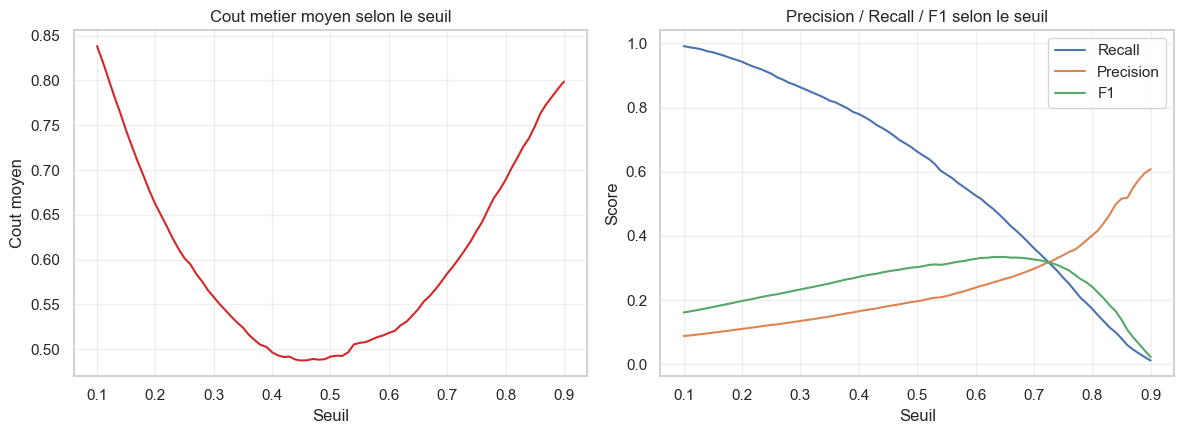

Meilleur seuil métier : 0.45
Coût métier validation : 0.487206
Best iteration : 298


,threshold,business_cost_per_obs,business_fbeta,precision,recall,f1,pr_auc,roc_auc
0,0.45,0.487206,0.569347,0.180718,0.725327,0.289344,0.275857,0.786382
1,0.46,0.487510,0.564809,0.183814,0.712487,0.292235,0.275857,0.786382
2,0.48,0.488161,0.555798,0.190383,0.687815,0.298221,0.275857,0.786382
3,0.44,0.488283,0.572519,0.177499,0.736405,0.286050,0.275857,0.786382
4,0.49,0.488649,0.551447,0.193602,0.676485,0.301048,0.275857,0.786382
5,0.47,0.488933,0.559172,0.186801,0.698389,0.294761,0.275857,0.786382
6,0.42,0.491189,0.578634,0.171090,0.759567,0.279274,0.275857,0.786382
7,0.43,0.491535,0.574135,0.173658,0.746224,0.281749,0.275857,0.786382
8,0.50,0.491596,0.544929,0.196054,0.662890,0.302609,0.275857,0.786382
9,0.52,0.492368,0.535706,0.203998,0.639728,0.309350,0.275857,0.786382


In [5]:
X_threshold_train, X_threshold_valid, y_threshold_train, y_threshold_valid = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=random_state,
    stratify=y_model,
)

threshold_model = clone(tuned_model)
best_iteration = None

if selected_model_name == "lightgbm_bonus" and lgb is not None:
    threshold_model.fit(
        X_threshold_train,
        y_threshold_train,
        eval_set=[(X_threshold_valid, y_threshold_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    best_iteration = int(
        threshold_model.best_iteration_
        or threshold_model.get_params().get("n_estimators", 300)
    )
else:
    threshold_model.fit(X_threshold_train, y_threshold_train)
    if selected_model_name == "hist_gradient_boosting":
        best_iteration = int(
            getattr(
                threshold_model,
                "n_iter_",
                threshold_model.get_params().get("max_iter", 300),
            )
        )

valid_scores = score_to_probability(threshold_model, X_threshold_valid)
threshold_df, best_threshold_row = threshold_search(
    y_true=y_threshold_valid,
    y_scores=valid_scores,
    thresholds=threshold_grid,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
)
best_threshold = float(best_threshold_row["threshold"])

threshold_summary_df = (
    threshold_df[
        [
            "threshold",
            "business_cost_per_obs",
            "business_fbeta",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "roc_auc",
        ]
    ]
    .sort_values(["business_cost_per_obs", "pr_auc", "recall"], ascending=[True, False, False])
    .head(10)
    .reset_index(drop=True)
)

threshold_report_path = report_dir / f"{selected_model_name}_threshold_report.csv"
threshold_top_path = report_dir / f"{selected_model_name}_threshold_top10.csv"
threshold_fig_path = report_dir / f"{selected_model_name}_threshold_diagnostics.png"

threshold_df.to_csv(threshold_report_path, index=False)
threshold_summary_df.to_csv(threshold_top_path, index=False)

threshold_fig = plot_threshold_diagnostics(threshold_df)
save_figure(threshold_fig, threshold_fig_path)
plt.show()
plt.close(threshold_fig)

mlflow.log_metric("selected_threshold", best_threshold)
mlflow.log_metric("threshold_valid_business_cost", float(best_threshold_row["business_cost_per_obs"]))
mlflow.log_artifact(str(threshold_report_path), artifact_path="tables")
mlflow.log_artifact(str(threshold_top_path), artifact_path="tables")
mlflow.log_artifact(str(threshold_fig_path), artifact_path="figures")

if best_iteration is not None:
    mlflow.log_metric("best_iteration", best_iteration)

print("Meilleur seuil métier :", round(best_threshold, 4))
print("Coût métier validation :", round(float(best_threshold_row["business_cost_per_obs"]), 6))
if best_iteration is not None:
    print("Best iteration :", best_iteration)

display(threshold_summary_df)


## 5. Test final sur le holdout sanctuarisé

On réalise maintenant la comparaison la plus importante du notebook :

- la baseline initiale du modèle retenu ;
- le modèle optimisé avec seuil par défaut `0.5` ;
- le modèle optimisé avec seuil métier.

C'est ici que l'on met en regard les performances techniques et le coût métier final.
Le tableau de sortie reprend volontairement le même format que dans le notebook 02 :
`train_accuracy`, `test_accuracy`, `train_f1`, `test_f1`,
`train_business_fbeta`, `test_business_fbeta`, `train_roc_auc`,
`test_roc_auc`, `train_pr_auc`, `test_pr_auc`.


In [6]:
baseline_model_full = build_optimization_candidate(
    model_name=selected_model_name,
    random_state=random_state,
    lightgbm_device_type=lightgbm_device_type,
)
if selected_model_name == "lightgbm_bonus" and lightgbm_gpu_target is not None:
    baseline_model_full.set_params(
        gpu_platform_id=lightgbm_gpu_target["gpu_platform_id"],
        gpu_device_id=lightgbm_gpu_target["gpu_device_id"],
    )
baseline_model_full.fit(X_model, y_model)
baseline_train_scores = score_to_probability(baseline_model_full, X_model)
baseline_holdout_scores = score_to_probability(baseline_model_full, X_holdout)
baseline_train_metrics = classification_metrics_at_threshold(
    y_true=y_model,
    y_scores=baseline_train_scores,
    threshold=0.5,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
)
baseline_holdout_metrics = classification_metrics_at_threshold(
    y_true=y_holdout,
    y_scores=baseline_holdout_scores,
    threshold=0.5,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
)

final_model = clone(tuned_model)
if selected_model_name == "lightgbm_bonus" and best_iteration is not None:
    final_model.set_params(n_estimators=best_iteration)
if selected_model_name == "hist_gradient_boosting" and best_iteration is not None:
    final_model.set_params(max_iter=best_iteration)

final_model.fit(X_model, y_model)
tuned_train_scores = score_to_probability(final_model, X_model)
tuned_holdout_scores = score_to_probability(final_model, X_holdout)

tuned_train_metrics_default = classification_metrics_at_threshold(
    y_true=y_model,
    y_scores=tuned_train_scores,
    threshold=0.5,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
)
tuned_holdout_metrics_default = classification_metrics_at_threshold(
    y_true=y_holdout,
    y_scores=tuned_holdout_scores,
    threshold=0.5,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
)
tuned_train_metrics_business = classification_metrics_at_threshold(
    y_true=y_model,
    y_scores=tuned_train_scores,
    threshold=best_threshold,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
)
tuned_holdout_metrics_business = classification_metrics_at_threshold(
    y_true=y_holdout,
    y_scores=tuned_holdout_scores,
    threshold=best_threshold,
    fn_cost=business_fn_cost,
    fp_cost=business_fp_cost,
)

holdout_comparison_df = pd.DataFrame(
    [
        build_holdout_metric_row(
            version="baseline_default_0_5",
            threshold=0.5,
            metrics=baseline_holdout_metrics,
        ),
        build_holdout_metric_row(
            version="tuned_default_0_5",
            threshold=0.5,
            metrics=tuned_holdout_metrics_default,
        ),
        build_holdout_metric_row(
            version=f"tuned_business_threshold_{best_threshold:.2f}",
            threshold=best_threshold,
            metrics=tuned_holdout_metrics_business,
        ),
    ]
)

aligned_run_comparison_df = pd.DataFrame(
    [
        build_train_test_metric_row(
            version="baseline_default_0_5",
            threshold=0.5,
            train_metrics=baseline_train_metrics,
            test_metrics=baseline_holdout_metrics,
        ),
        build_train_test_metric_row(
            version="tuned_default_0_5",
            threshold=0.5,
            train_metrics=tuned_train_metrics_default,
            test_metrics=tuned_holdout_metrics_default,
        ),
        build_train_test_metric_row(
            version=f"tuned_business_threshold_{best_threshold:.2f}",
            threshold=best_threshold,
            train_metrics=tuned_train_metrics_business,
            test_metrics=tuned_holdout_metrics_business,
        ),
    ]
)

final_test_scores = score_to_probability(final_model, X_test)
test_scoring = pd.DataFrame(
    {
        "SK_ID_CURR": test_ids,
        "TARGET_PROBA": final_test_scores,
        "TARGET_PRED_DEFAULT_0_5": (final_test_scores >= 0.5).astype(int),
        "TARGET_PRED_BUSINESS_THRESHOLD": (final_test_scores >= best_threshold).astype(int),
    }
)

holdout_comparison_path = report_dir / f"{selected_model_name}_holdout_comparison.csv"
aligned_run_comparison_path = report_dir / f"{selected_model_name}_train_test_comparison.csv"
test_scoring_path = processed_dir / "submission_like_test_scoring.csv"

holdout_comparison_df.to_csv(holdout_comparison_path, index=False)
aligned_run_comparison_df.to_csv(aligned_run_comparison_path, index=False)
test_scoring.to_csv(test_scoring_path, index=False)

log_train_test_metric_group(
    "baseline",
    baseline_train_metrics,
    baseline_holdout_metrics,
)
log_train_test_metrics(
    tuned_train_metrics_default,
    tuned_holdout_metrics_default,
)
log_train_test_metric_group(
    "business_threshold",
    tuned_train_metrics_business,
    tuned_holdout_metrics_business,
)
log_metric_group("baseline_holdout", baseline_holdout_metrics)
log_metric_group("tuned_holdout_default", tuned_holdout_metrics_default)
log_metric_group("tuned_holdout_business", tuned_holdout_metrics_business)

mlflow.log_artifact(str(holdout_comparison_path), artifact_path="tables")
mlflow.log_artifact(str(aligned_run_comparison_path), artifact_path="tables")
mlflow.log_artifact(str(test_scoring_path), artifact_path="tables")

display(aligned_run_comparison_df)
display(holdout_comparison_df)
display(test_scoring.head())


,version,train_accuracy,test_accuracy,train_f1,test_f1,train_business_fbeta,test_business_fbeta,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc,train_business_cost_per_obs,test_business_cost_per_obs,threshold
0,baseline_default_0_5,0.758314,0.743927,0.344982,0.301689,0.639038,0.556560,0.853633,0.787231,0.365799,0.286739,0.395451,0.484797,0.50
1,tuned_default_0_5,0.768253,0.748772,0.361200,0.303162,0.661592,0.552978,0.869774,0.787781,0.383916,0.287440,0.368647,0.485952,0.50
2,tuned_business_threshold_0.45,0.723733,0.705213,0.335683,0.285545,0.672067,0.568833,0.869774,0.787781,0.383916,0.287440,0.374643,0.491171,0.45


,version,threshold,accuracy,f1,business_fbeta,roc_auc,pr_auc,business_cost_per_obs,precision,recall
0,baseline_default_0_5,0.50,0.743927,0.301689,0.556560,0.787231,0.286739,0.484797,0.193427,0.685196
1,tuned_default_0_5,0.50,0.748772,0.303162,0.552978,0.787781,0.287440,0.485952,0.195316,0.676939
2,tuned_business_threshold_0.45,0.45,0.705213,0.285545,0.568833,0.787781,0.287440,0.491171,0.177502,0.729708


,SK_ID_CURR,TARGET_PROBA,TARGET_PRED_DEFAULT_0_5,TARGET_PRED_BUSINESS_THRESHOLD
0,100001,0.292117,0,0
1,100005,0.551701,1,1
2,100013,0.251423,0,0
3,100028,0.265816,0,0
4,100038,0.672507,1,1


## 6. Explicabilité globale

On produit ici deux niveaux d'explication globale :

- une importance native du modèle quand elle existe ;
- une permutation importance sur le holdout.

Cela permet de garder une lecture à la fois rapide et plus robuste des variables les plus influentes.


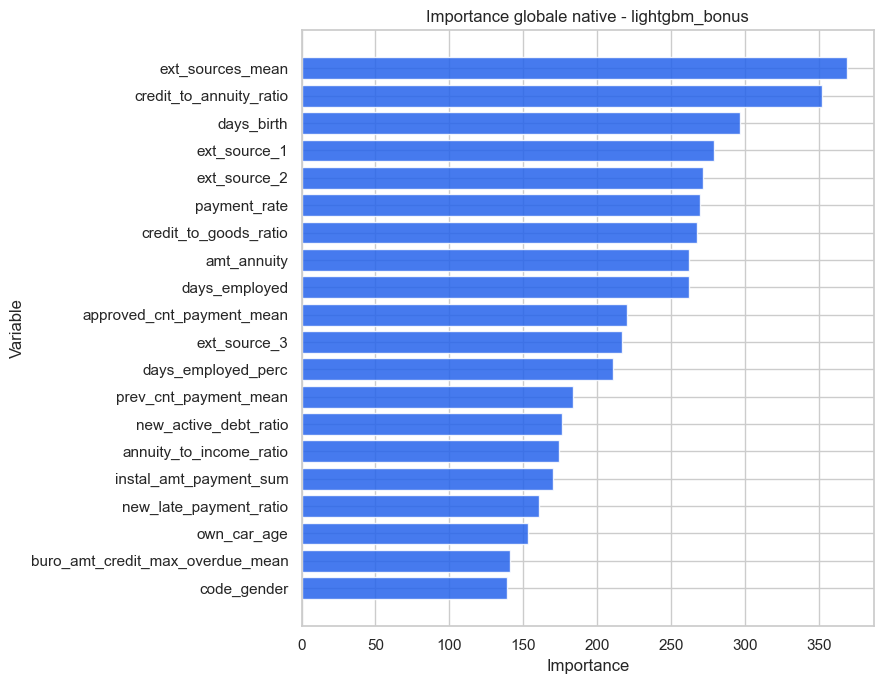

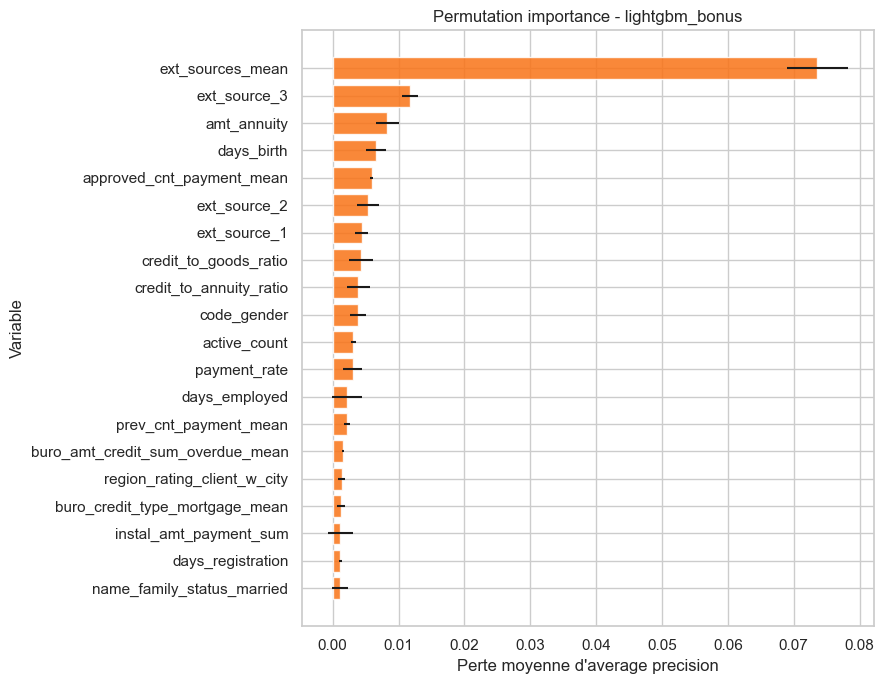

,feature,importance,importance_type
0,ext_sources_mean,369.0,feature_importances_
1,credit_to_annuity_ratio,352.0,feature_importances_
2,days_birth,297.0,feature_importances_
3,ext_source_1,279.0,feature_importances_
4,ext_source_2,272.0,feature_importances_
5,payment_rate,270.0,feature_importances_
6,credit_to_goods_ratio,268.0,feature_importances_
7,amt_annuity,262.0,feature_importances_
8,days_employed,262.0,feature_importances_
9,approved_cnt_payment_mean,220.0,feature_importances_


,feature,importance_mean,importance_std
0,ext_sources_mean,0.073600,0.004630
1,ext_source_3,0.011705,0.001209
2,amt_annuity,0.008298,0.001784
3,days_birth,0.006585,0.001564
4,approved_cnt_payment_mean,0.005901,0.000186
5,ext_source_2,0.005397,0.001628
6,ext_source_1,0.004393,0.000983
7,credit_to_goods_ratio,0.004350,0.001792
8,credit_to_annuity_ratio,0.003908,0.001688
9,code_gender,0.003869,0.001257


In [7]:
native_importance_df = compute_native_importance(final_model, X_model)
native_importance_path = report_dir / f"{selected_model_name}_native_importance.csv"
native_importance_df.to_csv(native_importance_path, index=False)

native_fig_path = None
if not native_importance_df.empty:
    top_native = native_importance_df.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top_native["feature"], top_native["importance"], color="#2563EB", alpha=0.85)
    ax.set_title(f"Importance globale native - {selected_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Variable")
    fig.tight_layout()
    native_fig_path = report_dir / f"{selected_model_name}_native_importance.png"
    save_figure(fig, native_fig_path)
    plt.show()
    plt.close(fig)

permutation_sample_size = min(15000, len(X_holdout))
X_perm = X_holdout.sample(n=permutation_sample_size, random_state=random_state)
y_perm = y_holdout.loc[X_perm.index]
permutation = permutation_importance(
    final_model,
    X_perm,
    y_perm,
    scoring="average_precision",
    n_repeats=5,
    random_state=random_state,
    n_jobs=-1,
)

permutation_importance_df = (
    pd.DataFrame(
        {
            "feature": X_perm.columns,
            "importance_mean": permutation.importances_mean,
            "importance_std": permutation.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
permutation_importance_path = report_dir / f"{selected_model_name}_permutation_importance.csv"
permutation_importance_df.to_csv(permutation_importance_path, index=False)

top_perm = permutation_importance_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
    color="#F97316",
    alpha=0.85,
)
ax.set_title(f"Permutation importance - {selected_model_name}")
ax.set_xlabel("Perte moyenne d'average precision")
ax.set_ylabel("Variable")
fig.tight_layout()
permutation_fig_path = report_dir / f"{selected_model_name}_permutation_importance.png"
save_figure(fig, permutation_fig_path)
plt.show()
plt.close(fig)

mlflow.log_artifact(str(native_importance_path), artifact_path="tables")
mlflow.log_artifact(str(permutation_importance_path), artifact_path="tables")
mlflow.log_artifact(str(permutation_fig_path), artifact_path="figures")
if native_fig_path is not None:
    mlflow.log_artifact(str(native_fig_path), artifact_path="figures")

display(native_importance_df.head(15))
display(permutation_importance_df.head(15))


## 7. Explicabilité locale et enregistrement final

Si le modèle et l'environnement le permettent, on complète l'analyse avec SHAP :

- une vue globale sur un échantillon ;
- une explication locale pour un client à score élevé.

Ensuite seulement, on enregistre le modèle final dans la registry MLflow.


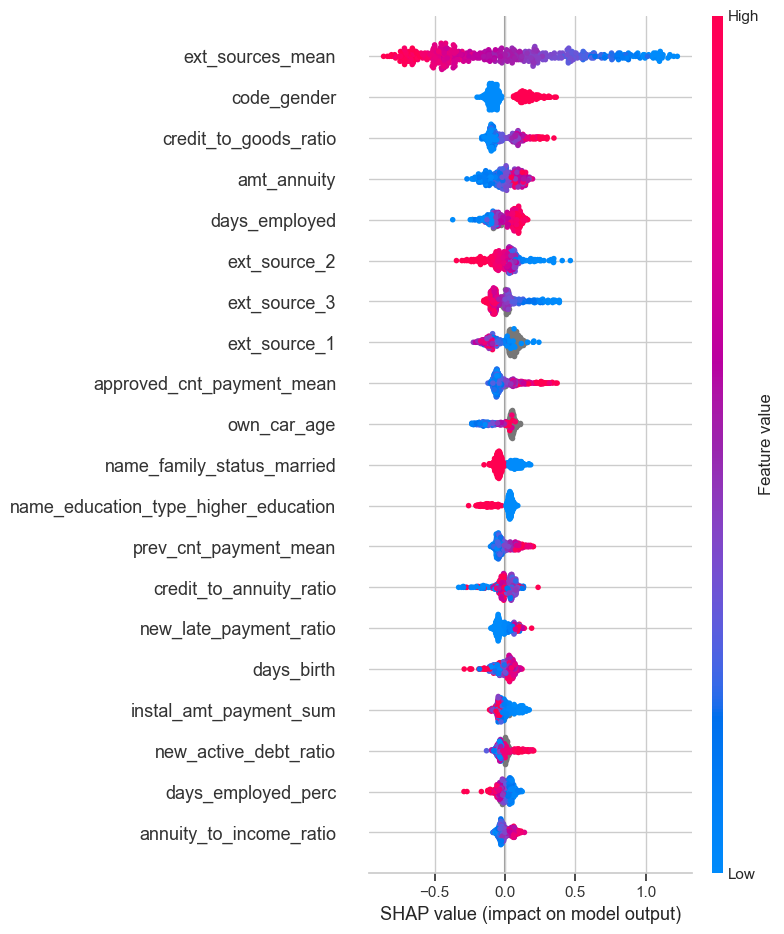

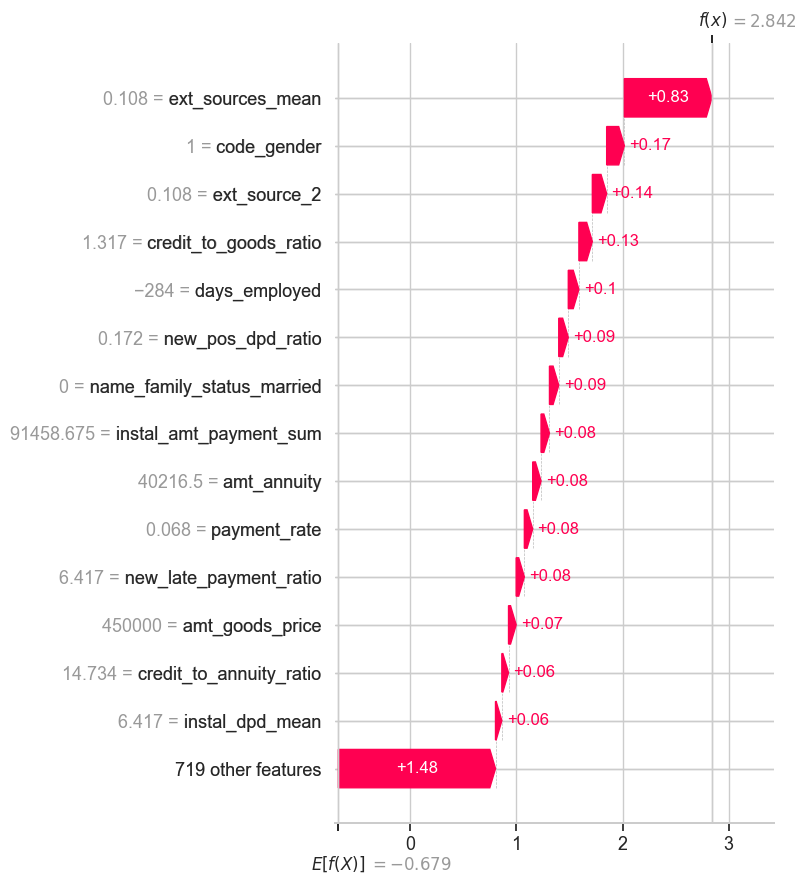

2026/04/17 12:46:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 12:46:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run MLflow : 3cbd616573b04448a11df30bab157612
MLflow cleanup status : ended:3cbd616573b04448a11df30bab157612
Registered model : P6_HOME_CREDIT_DEFAULT_RISK_MODEL
Registered version : 1
Statut SHAP : SHAP global et local produits avec succès.
Client expliqué : 163956


Registered model 'P6_HOME_CREDIT_DEFAULT_RISK_MODEL' already exists. Creating a new version of this model...
Created version '1' of model 'P6_HOME_CREDIT_DEFAULT_RISK_MODEL'.


In [8]:
shap_status = "SHAP non exécuté."
shap_summary_path = None
local_shap_path = None
client_id_to_explain = None

if shap_available and selected_model_name in {
    "lightgbm_bonus",
    "hist_gradient_boosting",
    "random_forest",
    "extra_trees",
}:
    try:
        core_model, transformed_model = prepare_explainability_frame(final_model, X_model)
        _, transformed_holdout = prepare_explainability_frame(final_model, X_holdout)

        shap_sample = transformed_holdout.sample(
            n=min(500, len(transformed_holdout)),
            random_state=random_state,
        )
        tree_explainer = shap.TreeExplainer(core_model)
        shap_values_sample = tree_explainer.shap_values(shap_sample)

        if isinstance(shap_values_sample, list):
            shap_matrix = shap_values_sample[1] if len(shap_values_sample) > 1 else shap_values_sample[0]
        else:
            shap_matrix = shap_values_sample

        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_matrix, shap_sample, max_display=20, show=False)
        shap_summary_path = explain_dir / f"{selected_model_name}_shap_summary.png"
        plt.tight_layout()
        plt.savefig(shap_summary_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

        client_position = int(np.argmax(tuned_holdout_scores))
        client_id_to_explain = int(ids_holdout.iloc[client_position])
        client_index = X_holdout.index[client_position]
        client_to_explain = transformed_holdout.loc[[client_index]]

        client_shap_values = tree_explainer.shap_values(client_to_explain)
        if isinstance(client_shap_values, list):
            client_shap_vector = client_shap_values[1][0] if len(client_shap_values) > 1 else client_shap_values[0][0]
            expected_values = np.atleast_1d(tree_explainer.expected_value)
            expected_value = expected_values[1] if len(expected_values) > 1 else expected_values[0]
        else:
            client_shap_vector = client_shap_values[0]
            expected_value = tree_explainer.expected_value

        waterfall_explanation = shap.Explanation(
            values=client_shap_vector,
            base_values=expected_value,
            data=client_to_explain.iloc[0].values,
            feature_names=client_to_explain.columns.tolist(),
        )

        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(waterfall_explanation, max_display=15, show=False)
        local_shap_path = explain_dir / f"{selected_model_name}_shap_waterfall_client_{client_id_to_explain}.png"
        plt.tight_layout()
        plt.savefig(local_shap_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

        shap_status = "SHAP global et local produits avec succès."
    except Exception as exc:
        shap_status = f"SHAP non produit : {exc}"
elif not shap_available:
    shap_status = "SHAP n'est pas installé dans l'environnement."
else:
    shap_status = (
        "SHAP local n'est pas calculé pour cette famille de modèle dans ce notebook ; "
        "la permutation importance reste disponible."
    )

shap_status_path = report_dir / f"{selected_model_name}_shap_status.txt"
shap_status_path.write_text(shap_status, encoding="utf-8")
mlflow.log_artifact(str(shap_status_path), artifact_path="tables")

if shap_summary_path is not None:
    mlflow.log_artifact(str(shap_summary_path), artifact_path="figures")
if local_shap_path is not None:
    mlflow.log_artifact(str(local_shap_path), artifact_path="figures")

logged_model = mlflow.sklearn.log_model(final_model, name="model")
model_version = register_model_version(
    model_uri=logged_model,
    client=tracking_context.client,
    registered_model_name=DEFAULT_REGISTERED_MODEL_NAME,
    model_version_tags={
        "stage": "optimization_threshold_explainability",
        "selected_model_name": selected_model_name,
        "selected_threshold": best_threshold,
        "notebook": "03_OPTIMISATION_SEUIL_EXPLICABILITE",
    },
)
mlflow.log_param("registered_model_version", model_version.version)

run_id = run.info.run_id
mlflow_cleanup_status = safe_end_active_run()

print("Run MLflow :", run_id)
print("MLflow cleanup status :", mlflow_cleanup_status)
print("Registered model :", DEFAULT_REGISTERED_MODEL_NAME)
print("Registered version :", model_version.version)
print("Statut SHAP :", shap_status)
if client_id_to_explain is not None:
    print("Client expliqué :", client_id_to_explain)


## 8. Conclusion et lecture métier

La conclusion doit relier trois niveaux :

- la qualité de la baseline issue du notebook 02 ;
- le gain apporté par le tuning des hyperparamètres ;
- l'effet concret du seuil métier sur la décision finale.


In [11]:
cost_gain_vs_baseline = (
    float(baseline_holdout_metrics["business_cost_per_obs"])
    - float(tuned_holdout_metrics_business["business_cost_per_obs"])
)
business_fbeta_gain_vs_baseline = (
    float(tuned_holdout_metrics_business["business_fbeta"])
    - float(baseline_holdout_metrics["business_fbeta"])
)
pr_auc_gain_vs_baseline = (
    float(tuned_holdout_metrics_default["pr_auc"])
    - float(baseline_holdout_metrics["pr_auc"])
)
roc_auc_gain_vs_baseline = (
    float(tuned_holdout_metrics_default["roc_auc"])
    - float(baseline_holdout_metrics["roc_auc"])
)

conclusion_markdown = f"""
## Conclusion

Le modèle optimisé dans ce notebook est **`{selected_model_name}`** (`{selected_model_family}`), directement repris de la recommandation du notebook 02.

### Ce que montre l'optimisation

- en validation croisée, la version tunée améliore le point de départ baseline sur les métriques les plus utiles au projet ;
- sur le holdout, la comparaison clé reste le **coût métier moyen**, qui passe de **{baseline_holdout_metrics['business_cost_per_obs']:.4f}** à **{tuned_holdout_metrics_business['business_cost_per_obs']:.4f}** avec le seuil métier ;
- au seuil par défaut `0.5`, le modèle optimisé atteint une **PR-AUC holdout** de **{tuned_holdout_metrics_default['pr_auc']:.4f}** et une **ROC-AUC holdout** de **{tuned_holdout_metrics_default['roc_auc']:.4f}**.

### Ce que change le seuil métier

- seuil retenu sur validation : **{best_threshold:.2f}** ;
- gain de coût métier sur holdout par rapport à la baseline : **{cost_gain_vs_baseline:.4f}** ;
- gain de **business F-beta** : **{business_fbeta_gain_vs_baseline:.4f}** ;
- variation de **PR-AUC** : **{pr_auc_gain_vs_baseline:.4f}** ;
- variation de **ROC-AUC** : **{roc_auc_gain_vs_baseline:.4f}**.

### Décision projet

On retient donc :

1. le **modèle optimisé** comme version candidate finale ;
2. le **seuil métier optimisé** pour la décision de scoring ;
3. les **artefacts MLflow**, d'explicabilité et de registry pour assurer la traçabilité complète.

"""

display(Markdown(conclusion_markdown))



## Conclusion

Le modèle optimisé dans ce notebook est **`lightgbm_bonus`** (`Boosting externe`), directement repris de la recommandation du notebook 02.

### Ce que montre l'optimisation

- en validation croisée, la version tunée améliore le point de départ baseline sur les métriques les plus utiles au projet ;
- sur le holdout, la comparaison clé reste le **coût métier moyen**, qui passe de **0.4848** à **0.4912** avec le seuil métier ;
- au seuil par défaut `0.5`, le modèle optimisé atteint une **PR-AUC holdout** de **0.2874** et une **ROC-AUC holdout** de **0.7878**.

### Ce que change le seuil métier

- seuil retenu sur validation : **0.45** ;
- gain de coût métier sur holdout par rapport à la baseline : **-0.0064** ;
- gain de **business F-beta** : **0.0123** ;
- variation de **PR-AUC** : **0.0007** ;
- variation de **ROC-AUC** : **0.0006**.

### Décision projet

On retient donc :

1. le **modèle optimisé** comme version candidate finale ;
2. le **seuil métier optimisé** pour la décision de scoring ;
3. les **artefacts MLflow**, d'explicabilité et de registry pour assurer la traçabilité complète.

